In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ddeint import ddeint
from scipy.signal import find_peaks
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
climate_api_data = pd.read_csv("../../data_files/data/climate_api_data_2016_2024.csv")
cases_data = pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv")

# Convert date columns to datetime
climate_api_data['date'] = pd.to_datetime(climate_api_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])

# Filter to study period
start_date = '2017-01-01'
end_date = '2023-12-31'

climate_api_data = climate_api_data[
    (climate_api_data['date'] >= start_date) & 
    (climate_api_data['date'] <= end_date)
].reset_index(drop=True)

cases_data = cases_data[
    (cases_data['date'] >= start_date) & 
    (cases_data['date'] <= end_date)
].reset_index(drop=True)

ibge_rural_pop_data_df_2016_2024 = pd.read_csv("../../data_files/data/ibge_manaus_fixed_rural_population_data_2016_2024.csv")

# Filter between dates
ibge_rural_pop_data_df_2016_2024['index'] = pd.to_datetime(ibge_rural_pop_data_df_2016_2024['index'])

# Create mask
mask = (ibge_rural_pop_data_df_2016_2024['index'] >= '2017-01-01') & (ibge_rural_pop_data_df_2016_2024['index'] <= '2023-12-31')
filtered_pop_df = ibge_rural_pop_data_df_2016_2024[mask]
filtered_pop_df = filtered_pop_df.reset_index().drop(columns=['level_0'])

In [3]:
cases_data

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2017-01-01,2273,1963,310,2,10906,2017,1,52,1,757.666667
1,2017-01-02,2274,1962,312,4,10910,2017,1,1,2,454.800000
2,2017-01-03,2254,1951,303,5,10915,2017,1,1,3,375.666667
3,2017-01-04,2236,1936,300,1,10916,2017,1,1,4,1118.000000
4,2017-01-05,2235,1935,300,0,10916,2017,1,1,5,2235.000000
...,...,...,...,...,...,...,...,...,...,...,...
2551,2023-12-27,1110,931,179,4,47424,2023,12,52,361,222.000000
2552,2023-12-28,1102,927,175,7,47431,2023,12,52,362,137.750000
2553,2023-12-29,1098,928,170,2,47433,2023,12,52,363,366.000000
2554,2023-12-30,1088,923,165,0,47433,2023,12,52,364,1088.000000


#### Approximation of Manaus rural data:

Based on /data_files/notebooks/Manaus_Population_Correction.ipynb, the approximate proportion of rural cases in the period of 2015 to 2019 was ~41.54$\%$ of the total cases. Taking this into estimation, we create an approximation of a rural cases dataframe below:

In [5]:
rural_cases_df = cases_data.copy()
rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']] = rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']]*(41.54/100)
rural_cases_df

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2017-01-01,944.2042,815.4302,128.7740,0.8308,4530.3524,2017,1,52,1,314.734733
1,2017-01-02,944.6196,815.0148,129.6048,1.6616,4532.0140,2017,1,1,2,188.923920
2,2017-01-03,936.3116,810.4454,125.8662,2.0770,4534.0910,2017,1,1,3,156.051933
3,2017-01-04,928.8344,804.2144,124.6200,0.4154,4534.5064,2017,1,1,4,464.417200
4,2017-01-05,928.4190,803.7990,124.6200,0.0000,4534.5064,2017,1,1,5,928.419000
...,...,...,...,...,...,...,...,...,...,...,...
2551,2023-12-27,461.0940,386.7374,74.3566,1.6616,19699.9296,2023,12,52,361,92.218800
2552,2023-12-28,457.7708,385.0758,72.6950,2.9078,19702.8374,2023,12,52,362,57.221350
2553,2023-12-29,456.1092,385.4912,70.6180,0.8308,19703.6682,2023,12,52,363,152.036400
2554,2023-12-30,451.9552,383.4142,68.5410,0.0000,19703.6682,2023,12,52,364,451.955200


The rural population is already estimated in the filtered_pop_df above.

In [7]:
# Model parameters
T_prime = 25.6  # Temperature threshold for biting rate

# Mosquito life cycle parameters
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 5.0  # Reduced to increase biting rate
b1 = 0.9  # Transmission probability: mosquito → human
b2 = 0.9  # Transmission probability: human → mosquito

# D1=36.5
# b1=0.9
# b2=0.9

A = 12.5
B = 15.0
C = -48.78
DD = 105       # Degree-days for P. vivax sporogony
Tmin = 14.5    # Minimum temperature for parasite development
gamma = 1/120   # Recovery rate (1/120 per day, ~120 days to recover)
R_L = 32.67    # Rainfall threshold for breeding sites (mm)
N = np.round(filtered_pop_df['daily_rural_pop'].iloc[0]) #8558       # Human population
M = 100000     # Base mosquito population (increased)

r_H = 0.00005  # Net human increase rate per capita

# NEW PARAMETERS FOR SEIRS MODEL:
tau_H = 10          # Human incubation period (days) - exposed to infectious
omega = 1/365       # Rate of immunity loss (1/365 per day = ~1 year of immunity)
                    # For P. vivax, immunity can wane; can be adjusted

# Mosquito initial conditions
E_M0 = 10000
I_M0 = 500  # Increased for more transmission

# # Get I_H0 from cases_data at the start date
# start_date_obj = pd.to_datetime(start_date)
# start_row = cases_data[cases_data['date'] == start_date_obj].iloc[0]
# I_H0 = start_row['active_total']

### Using rural cases instead
if 'active_symptomatic' in rural_cases_df.columns and 'active_asymptomatic' in rural_cases_df.columns:
    # Calculate total infectious cases
    #cases_data['total_infectious'] = cases_data['active_symptomatic'] + cases_data['active_asymptomatic']
    
    # Calculate proportion asymptomatic for model parameter
    rural_cases_df['prop_asymptomatic'] = rural_cases_df['active_asymptomatic'] / rural_cases_df['active_total']
    avg_prop_asymp = rural_cases_df['prop_asymptomatic'].mean()
    print(f"Average proportion asymptomatic: {avg_prop_asymp:.2f}")
    
    # Use total_infectious as I_H
    I_H_data = rural_cases_df['active_total'].values
    I_H0 = I_H_data[0]  # Initial infectious at start date
    
    # You can also estimate:
    # - E_H0 might be inferred from I_H0 and incubation period
    # - Or use a fraction of I_H0 (common: E_H0 ≈ I_H0)
    E_H0 = I_H0 * 0.5  # Rough estimate: half as many exposed as infectious
    
elif 'cumulative_cases' in rural_cases_df.columns:
    # If you only have cumulative cases, calculate new cases per day
    rural_cases_df['new_cases'] = rural_cases_df['cumulative_cases'].diff().fillna(0)
    I_H_data = rural_cases_df['new_cases'].values
    I_H0 = I_H_data[0]
    
    # Estimate E_H0 from I_H0 and incubation period
    # New cases today ≈ were exposed tau_H days ago
    E_H0 = I_H0 * tau_H / (1/gamma)  # Rough approximation
    
else:
    # Fallback: if you only have active cases (as in this case)
    I_H_data = rural_cases_df['active_total'].values
    I_H0 = I_H_data[0]
    E_H0 = I_H0 * 0.5  # Estimate

print(f"Initial I_H0: {I_H0}")
print(f"Initial E_H0: {E_H0}")

# print(f"I_H0 (active cases at {start_date}): {I_H0}")
print(f"tau_H (human incubation period): {tau_H} days")
print(f"omega (immunity loss rate): {omega:.6f} per day (~{1/omega:.0f} days immunity)")

# Initial conditions: [S_H, E_H, I_H, R_H, S_M, E_M, I_M]
S_H0 = N - E_H0 - I_H0 - 0  # No recovered initially
R_H0 = 0
S_M0 = M - E_M0 - I_M0

initial_state = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])

Average proportion asymptomatic: 0.12
Initial I_H0: 944.2042
Initial E_H0: 472.1021
tau_H (human incubation period): 10 days
omega (immunity loss rate): 0.002740 per day (~365 days immunity)


In [8]:
def tau_L(Temp):
    """Larval development duration"""
    denom = c1 * Temp + c2
    if denom <= 0:
        return 100
    return 1 / denom

def p_T(Temp):
    """Daily mosquito survival probability"""
    denom = A * Temp**2 + B * Temp + C
    if denom >= 0:
        return 0.85
    return np.exp(-1 / denom)

def p_LT(Temp):
    """Larval survival probability"""
    exponent = c1 * Temp + c2
    if exponent > 10:
        return 0
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    """Larval survival probability due to rain"""
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)

def p_ER(Rain, R_L):
    """Egg survival probability due to rain"""
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)

def p_PR(Rain, R_L):
    """Pupal survival probability due to rain"""
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)

def tau_M(Temp):
    """Sporogonic cycle duration"""
    if Temp <= Tmin:
        return 50
    return DD / (Temp - Tmin)

def mu(Temp):
    """Mosquito mortality rate"""
    p_T_val = p_T(Temp)
    if p_T_val <= 0:
        return 0.15
    mu_val = -np.log(p_T_val)
    return min(mu_val, 0.3)

def a(Temp):
    """Mosquito biting rate"""
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return np.minimum(a_val, 0.8)

def b_rate(Rain, Temp, R_L):
    """Mosquito recruitment rate"""
    tau_L_curr = tau_L(Temp)
    if tau_L_curr <= 0:
        return 0
    
    numerator = B_E * p_ER(Rain, R_L) * p_LR(Rain, R_L) * p_LT(Temp) * p_PR(Rain, R_L)
    denominator = tau_E + tau_L_curr + tau_P
    if denominator <= 0:
        return 0
    return numerator / denominator

# NEW DDE MODEL: SEIRS-SEI
def dde_model(Y, t):
    """
    SEIRS-SEI DDE model for malaria transmission with waning immunity
    
    Human states: S_H, E_H, I_H, R_H
    Mosquito states: S_M, E_M, I_M
    
    Delays:
    - tau_H: human incubation period (exposed → infectious)
    - tau_M_safe: sporogonic cycle (mosquito exposed → infectious)
    """
    # Get current state
    try:
        S_H, E_H, I_H, R_H, S_M, E_M, I_M = Y(t)
    except:
        return np.zeros(7)
    
    # Clamp to prevent negative values
    S_H = max(S_H, 1e-6)
    E_H = max(E_H, 1e-6)
    I_H = max(I_H, 1e-6)
    R_H = max(R_H, 1e-6)
    S_M = max(S_M, 1e-6)
    E_M = max(E_M, 1e-6)
    I_M = max(I_M, 1e-6)
    
    # Get climate data for current time
    day_index = int(t)
    if day_index >= len(climate_api_data):
        day_index = len(climate_api_data) - 1
    if day_index < 0:
        day_index = 0
    
    T_curr = climate_api_data.loc[day_index, 'temp_med']
    R_curr = climate_api_data.loc[day_index, 'precip_med']
    
    # Get month for seasonality
    date_str = climate_api_data.loc[day_index, 'date']
    month = pd.to_datetime(date_str).month
    
    # Calculate current parameters
    a_curr = a(T_curr)
    mu_curr = mu(T_curr)
    tau_M_curr = tau_M(T_curr)
    
    # Climate-driven carrying capacity with STRONGER seasonal forcing
    temp_factor = max(0.1, min(1, (T_curr - 15) / 15))
    rain_factor = min(1, max(0, R_curr / 30))
    
    # Sinusoidal seasonal forcing - creates strong annual oscillations
    day_of_year = pd.to_datetime(date_str).dayofyear
    seasonal_phase = 2 * np.pi * (day_of_year - 180) / 365.25
    seasonal_factor = 2.5 + 2.0 * np.sin(seasonal_phase)  # Range: 0.5 to 4.5
    
    K = M * temp_factor * rain_factor * seasonal_factor
    
    # Mosquito recruitment with density dependence
    b_curr = b_rate(R_curr, T_curr, R_L)
    total_mosquitoes = S_M + E_M + I_M
    if K > 0:
        density_factor = max(0, 1 - total_mosquitoes / K)
    else:
        density_factor = 0
    mosquito_birth = b_curr * density_factor * K
    
    # ========== DELAYED STATES ==========
    
    # Delay 1: Human incubation period (exposed → infectious)
    tau_H_safe = min(max(tau_H, 1), 30)  # Cap between 1 and 30 days
    try:
        S_H_delay, E_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = Y(t - tau_H_safe)
        S_H_delay = max(S_H_delay, 0)
        E_H_delay = max(E_H_delay, 0)
        I_H_delay = max(I_H_delay, 0)
    except:
        # Use current state if delay fails
        S_H_delay, E_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = S_H, E_H, I_H, R_H, S_M, E_M, I_M
    
    # Delay 2: Sporogonic cycle (mosquito exposed → infectious)
    tau_M_safe = min(max(tau_M_curr, 1), 50)  # Cap between 1 and 50 days
    try:
        S_H_delay_M, E_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = Y(t - tau_M_safe)
        S_H_delay_M = max(S_H_delay_M, 0)
        I_H_delay_M = max(I_H_delay_M, 0)
        S_M_delay_M = max(S_M_delay_M, 0)
    except:
        S_H_delay_M, E_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = S_H, E_H, I_H, R_H, S_M, E_M, I_M
    
    # Probability of surviving sporogonic cycle
    l_curr = np.exp(-mu_curr * tau_M_safe)
    
    # ========== HUMAN EQUATIONS (SEIRS) ==========
    
    # Force of infection (rate at which susceptible humans become exposed)
    foi_human = a_curr * b2 * (I_M / N)
    
    # New exposures (susceptible → exposed)
    new_exposures_h = foi_human * S_H
    
    # Exposed become infectious after incubation period (E_H → I_H)
    # The number becoming infectious now = number that were exposed tau_H days ago
    # multiplied by survival probability (humans have negligible mortality during incubation)
    # Since humans don't have significant mortality, we use: foi_human(t - tau_H) * S_H(t - tau_H)
    foi_human_delay = a_curr * b2 * (I_M_delay / N)
    new_infections_h = foi_human_delay * S_H_delay
    
    # Infectious recover (I_H → R_H)
    recoveries = gamma * I_H
    
    # Recovered lose immunity and become susceptible again (R_H → S_H)
    immunity_loss = omega * R_H
    
    # Human differential equations (We don't consider death at rate r_H*k given that the population increased over this period)
    ### Based on changes of population data in relation to Trajetorias data, it can be seen that the rural population, in fact, decreases
    ### Because of this, r_H was initially removed from this version of the model
    dShdt = - new_exposures_h + immunity_loss #r_H * N - new_exposures_h + immunity_loss
    dEhdt = new_exposures_h - new_infections_h #- r_H * E_H
    dIhdt = new_infections_h - recoveries #- r_H * I_H
    dRhdt = recoveries - immunity_loss #- r_H * R_H
    
    # ========== MOSQUITO EQUATIONS (SEI) ==========
    
    # Force of infection for mosquitoes
    foi_mosquito = a_curr * b1 * (I_H / N)
    
    # New mosquito exposures (susceptible → exposed)
    new_exposures_m = foi_mosquito * S_M
    
    # Exposed mosquitoes become infectious after sporogonic cycle
    foi_mosquito_delay = a_curr * b1 * (I_H_delay_M / N)
    new_infections_m = foi_mosquito_delay * S_M_delay_M * l_curr
    
    # Mosquito differential equations
    dSmdt = mosquito_birth - new_exposures_m - mu_curr * S_M
    dEmdt = new_exposures_m - new_infections_m - mu_curr * E_M
    dImdt = new_infections_m - mu_curr * I_M
    
    # Ensure derivatives don't drive populations negative
    dShdt = max(dShdt, -S_H / 10)
    dEhdt = max(dEhdt, -E_H / 10)
    dIhdt = max(dIhdt, -I_H / 10)
    dRhdt = max(dRhdt, -R_H / 10)
    dSmdt = max(dSmdt, -S_M / 10)
    dEmdt = max(dEmdt, -E_M / 10)
    dImdt = max(dImdt, -I_M / 10)
    
    return [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [9]:
def history(t):
    """Return initial state for times t <= 0"""
    return initial_state

In [10]:
print("Solving SEIRS-SEI DDE...")
t_eval = np.linspace(0, 2556, 2557)  # 7 years, daily resolution
sol = ddeint(dde_model, history, t_eval)
print("Solution completed!")

# Extract results
S_H = sol[:, 0]
E_H = sol[:, 1]
I_H = sol[:, 2]
R_H = sol[:, 3]
S_M = sol[:, 4]
E_M = sol[:, 5]
I_M = sol[:, 6]

# Ensure no negative values
S_H = np.maximum(S_H, 0)
E_H = np.maximum(E_H, 0)
I_H = np.maximum(I_H, 0)
R_H = np.maximum(R_H, 0)
S_M = np.maximum(S_M, 0)
E_M = np.maximum(E_M, 0)
I_M = np.maximum(I_M, 0)

# Convert days to years
years = 2017 + t_eval / 365.25

# Create time array for climate data
climate_years = pd.date_range(start=start_date, end=end_date, freq='D')
climate_years = climate_years.year + (climate_years.dayofyear - 1) / 365.25

Solving SEIRS-SEI DDE...
Solution completed!


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


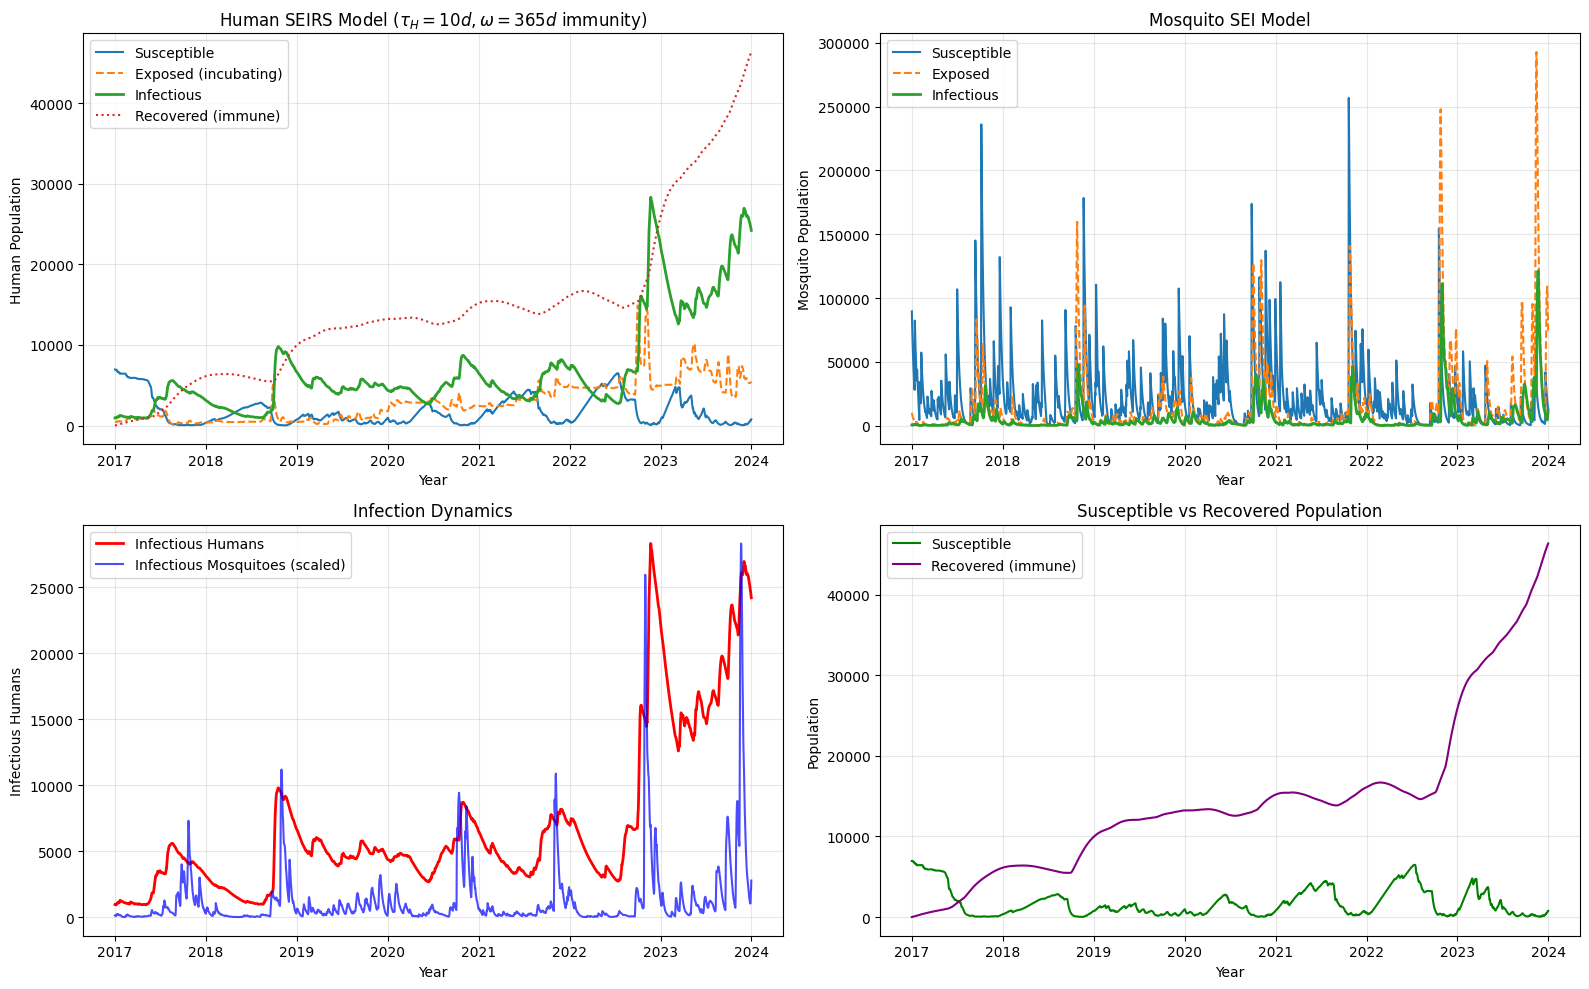

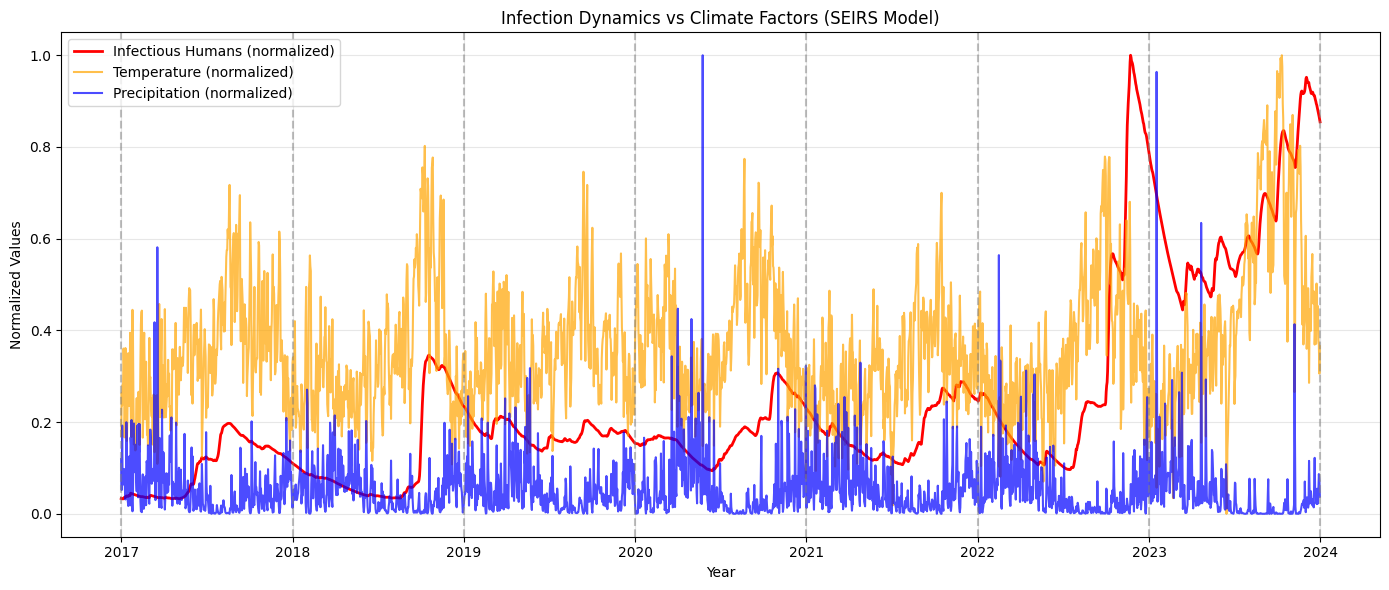

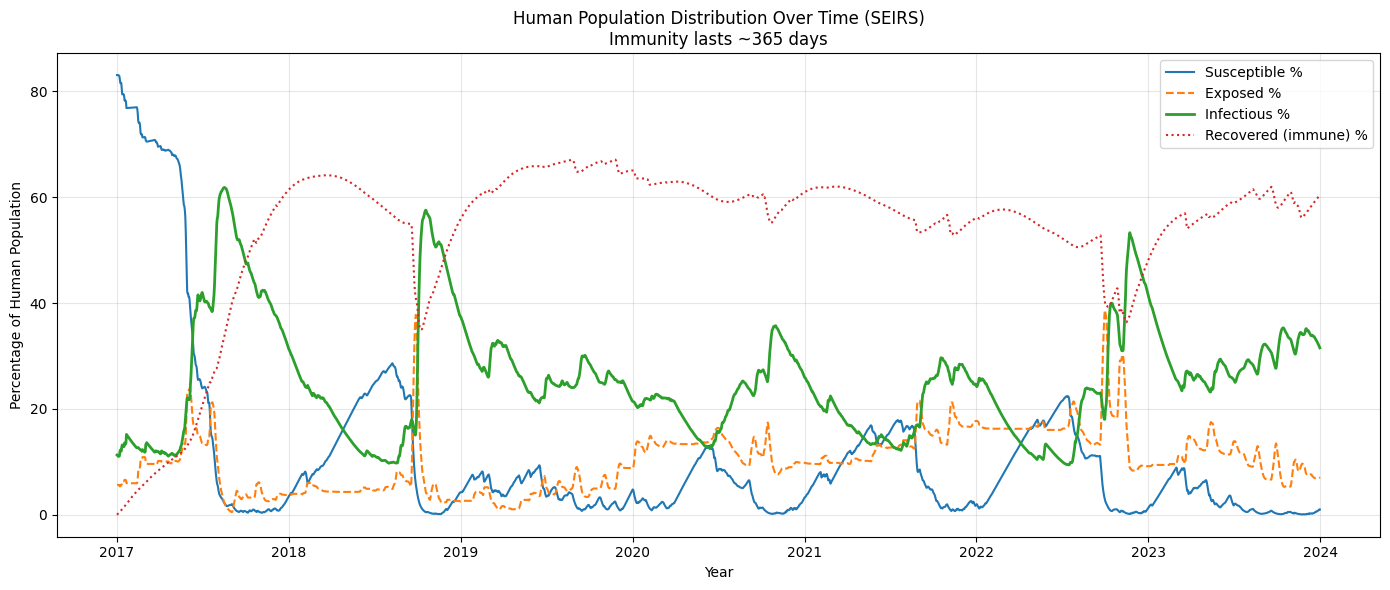

In [11]:
# Plot 1: Human populations (SEIRS)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Human populations
axes[0, 0].plot(years, S_H, label='Susceptible', linewidth=1.5)
axes[0, 0].plot(years, E_H, label='Exposed (incubating)', linewidth=1.5, linestyle='--')
axes[0, 0].plot(years, I_H, label='Infectious', linewidth=2)
axes[0, 0].plot(years, R_H, label='Recovered (immune)', linewidth=1.5, linestyle=':')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Human Population')
axes[0, 0].set_title(
    rf"Human SEIRS Model "
    rf"($\tau_H={tau_H} d, \omega={1/omega:.0f} d$"
    rf" immunity)"
                    )
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Mosquito populations (SEI)
axes[0, 1].plot(years, S_M, label='Susceptible', linewidth=1.5)
axes[0, 1].plot(years, E_M, label='Exposed', linewidth=1.5, linestyle='--')
axes[0, 1].plot(years, I_M, label='Infectious', linewidth=2)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Mosquito Population')
axes[0, 1].set_title('Mosquito SEI Model')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Infection dynamics
axes[1, 0].plot(years, I_H, 'r-', linewidth=2, label='Infectious Humans')
axes[1, 0].plot(years, I_M / max(I_M) * max(I_H) if max(I_M) > 0 else I_M, 
                'b-', linewidth=1.5, alpha=0.7, 
                label='Infectious Mosquitoes (scaled)')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Infectious Humans')
axes[1, 0].set_title('Infection Dynamics')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Susceptible vs Recovered dynamics
axes[1, 1].plot(years, S_H, 'g-', linewidth=1.5, label='Susceptible')
axes[1, 1].plot(years, R_H, 'purple', linewidth=1.5, label='Recovered (immune)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Population')
axes[1, 1].set_title('Susceptible vs Recovered Population')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Climate influence on infection
fig, ax = plt.subplots(figsize=(14, 6))

# Normalize for plotting
I_H_norm = I_H / max(I_H) if max(I_H) > 0 else I_H
temp_norm = (climate_api_data['temp_med'] - np.nanmin(climate_api_data['temp_med'])) / \
            (np.nanmax(climate_api_data['temp_med']) - np.nanmin(climate_api_data['temp_med']))
rain_norm = climate_api_data['precip_med'] / np.nanmax(climate_api_data['precip_med']) if np.nanmax(climate_api_data['precip_med']) > 0 else climate_api_data['precip_med']

ax.plot(years, I_H_norm, 'r-', linewidth=2, label='Infectious Humans (normalized)')
ax.plot(climate_years, temp_norm, 'orange', linewidth=1.5, alpha=0.7, label='Temperature (normalized)')
ax.plot(climate_years, rain_norm, 'blue', linewidth=1.5, alpha=0.7, label='Precipitation (normalized)')
ax.set_xlabel('Year')
ax.set_ylabel('Normalized Values')
ax.set_title('Infection Dynamics vs Climate Factors (SEIRS Model)')
ax.legend()
ax.grid(True, alpha=0.3)

# Add vertical lines for years
for year in range(2017, 2025):
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Plot 3: Compartment flows
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the fraction of population in each state
total_human = S_H + E_H + I_H + R_H
ax.plot(years, S_H / total_human * 100, label='Susceptible %', linewidth=1.5)
ax.plot(years, E_H / total_human * 100, label='Exposed %', linewidth=1.5, linestyle='--')
ax.plot(years, I_H / total_human * 100, label='Infectious %', linewidth=2)
ax.plot(years, R_H / total_human * 100, label='Recovered (immune) %', linewidth=1.5, linestyle=':')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage of Human Population')
ax.set_title(f'Human Population Distribution Over Time (SEIRS)\nImmunity lasts ~{1/omega:.0f} days')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

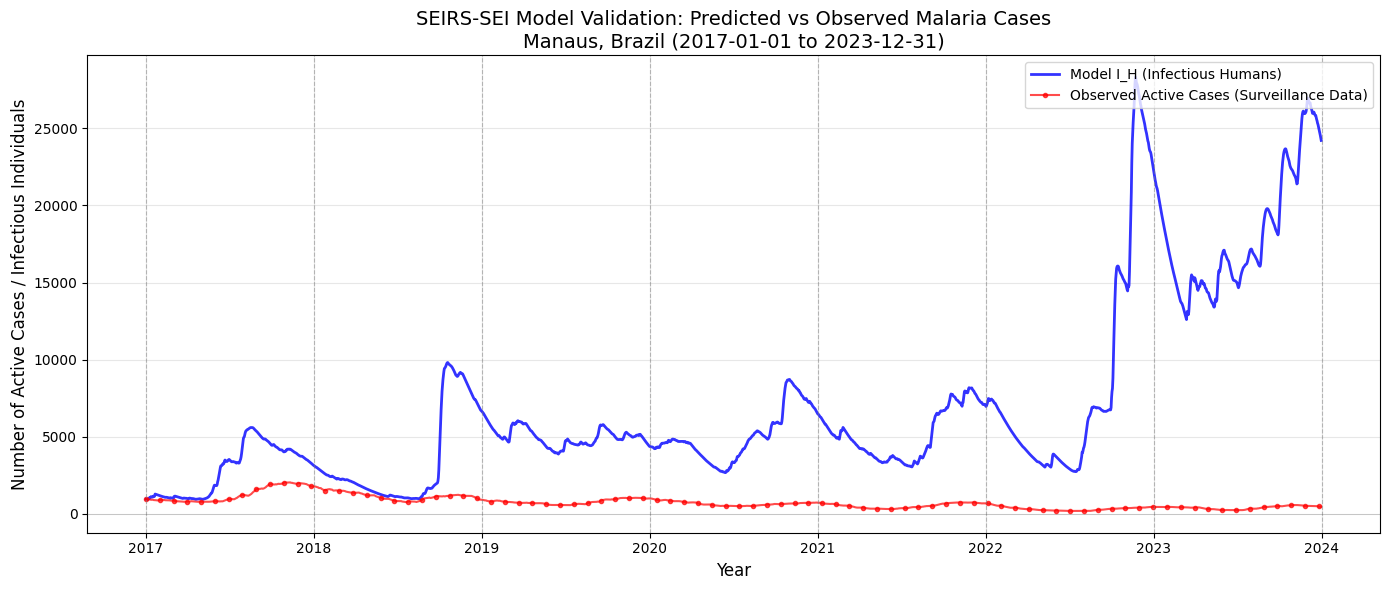

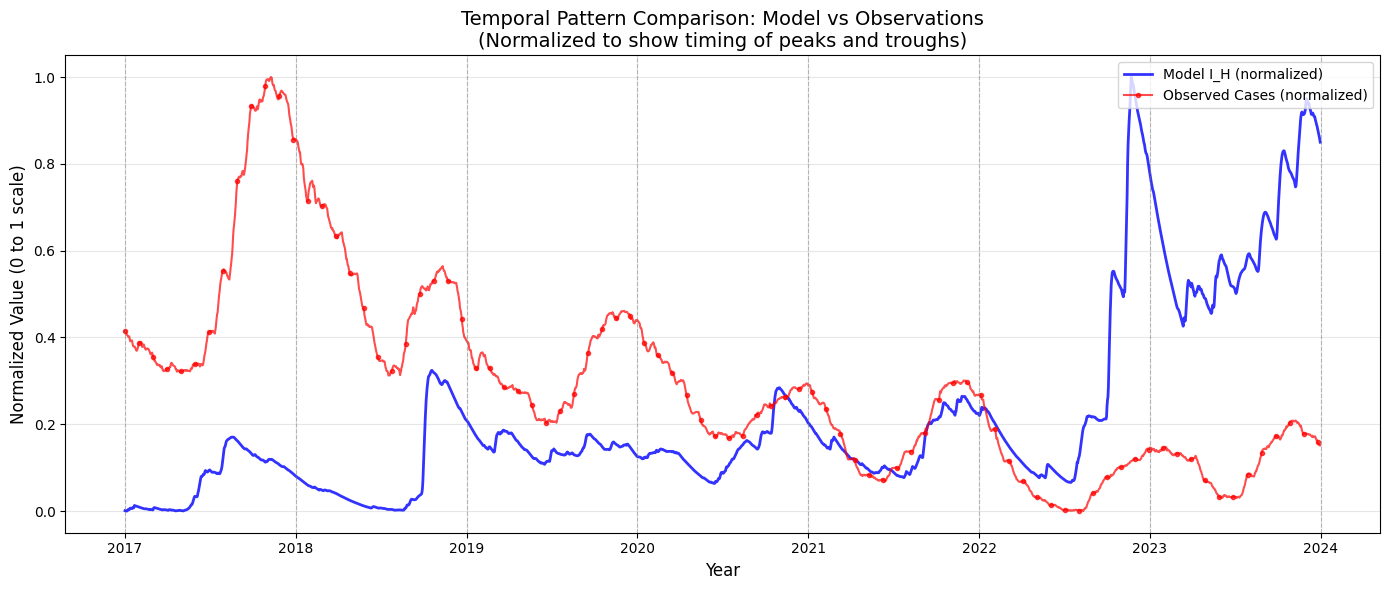

In [12]:
# ============================================================================
# PLOT 4: DIRECT COMPARISON - Model vs Observed Data
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Model output (I_H - infectious humans)
ax.plot(years, I_H, 'b-', linewidth=2, label='Model I_H (Infectious Humans)', alpha=0.8)

# Prepare observed data for plotting
# Convert dates to continuous years for proper alignment
obs_years = rural_cases_df['date'].dt.year.values + (rural_cases_df['date'].dt.dayofyear.values - 1) / 365.25

# Plot observed active cases
ax.plot(obs_years, rural_cases_df['active_total'].values, 'r-', linewidth=1.5, 
        label='Observed Active Cases (Surveillance Data)', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Active Cases / Infectious Individuals', fontsize=12)
ax.set_title('SEIRS-SEI Model Validation: Predicted vs Observed Malaria Cases\n' +
             f'Manaus, Brazil ({start_date} to {end_date})', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# Add vertical lines for year boundaries
for year in range(2017, 2025):
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

# Optional: Add horizontal line at zero
ax.axhline(y=0, color='black', linestyle='-', alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 5: NORMALIZED COMPARISON - Pattern Matching
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Normalize both time series to [0, 1] range for pattern comparison
# This removes magnitude differences to focus on temporal dynamics

# Normalize model output
if I_H.max() > I_H.min():
    I_H_norm = (I_H - I_H.min()) / (I_H.max() - I_H.min())
else:
    I_H_norm = I_H  # Handle constant series

# Normalize observed data
obs_values = rural_cases_df['active_total'].values
if obs_values.max() > obs_values.min():
    obs_norm = (obs_values - obs_values.min()) / (obs_values.max() - obs_values.min())
else:
    obs_norm = obs_values

# Plot normalized time series
ax.plot(years, I_H_norm, 'b-', linewidth=2, label='Model I_H (normalized)', alpha=0.8)
ax.plot(obs_years, obs_norm, 'r-', linewidth=1.5, label='Observed Cases (normalized)', 
        alpha=0.7, marker='o', markersize=3, markevery=30)

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Normalized Value (0 to 1 scale)', fontsize=12)
ax.set_title('Temporal Pattern Comparison: Model vs Observations\n' +
             '(Normalized to show timing of peaks and troughs)', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# Add vertical lines for year boundaries
for year in range(2017, 2025):
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.show()

In [13]:
print("\n" + "="*60)
print("SIMULATION STATISTICS (SEIRS Model)")
print("="*60)

# Find infection peaks
peaks, peak_props = find_peaks(I_H, distance=180)

print(f"\nNumber of infection waves detected: {len(peaks)}")
if len(peaks) > 0:
    print("\nPeak infections:")
    for i, peak_idx in enumerate(peaks):
        peak_year = years[peak_idx]
        peak_value = I_H[peak_idx]
        print(f"  Wave {i+1}: {peak_year:.2f}, Infections: {peak_value:.0f}")

# Summary statistics
avg_infected = np.mean(I_H[I_H > 0]) if np.any(I_H > 0) else 0
print(f"\nAverage infected population: {avg_infected:.0f}")
print(f"Peak infected population: {I_H.max():.0f}")
print(f"Peak exposed population: {E_H.max():.0f}")
print(f"Final susceptible population: {S_H[-1]:.0f}")
print(f"Final recovered/immune population: {R_H[-1]:.0f}")
print(f"Final exposed population: {E_H[-1]:.0f}")
print(f"Total infected over simulation: {sum(I_H):.0f} person-days")

# Calculate effective reproduction number estimate (simplified)
# R0 estimate = transmission rate * infectious period
# This is a rough approximation
avg_foi = np.mean(a(climate_api_data['temp_med'].values) * b2)
avg_infectious_period = 1/gamma
print(f"\nApproximate average R0 (basic reproduction number): {avg_foi * avg_infectious_period * N:.2f}")

print("\n" + "="*60)
print("MODEL NOTES:")
print("- SEIRS model allows recovered individuals to lose immunity and become susceptible again")
print(f"- Human incubation period (E→I): {tau_H} days")
print(f"- Average immunity duration: {1/omega:.0f} days (~{1/omega/365:.1f} years)")
print("- This is more realistic for P. vivax malaria which can relapse")
print("="*60)


SIMULATION STATISTICS (SEIRS Model)

Number of infection waves detected: 12

Peak infections:
  Wave 1: 2017.05, Infections: 1271
  Wave 2: 2017.63, Infections: 5591
  Wave 3: 2018.14, Infections: 2289
  Wave 4: 2018.80, Infections: 9807
  Wave 5: 2019.72, Infections: 5779
  Wave 6: 2020.22, Infections: 4636
  Wave 7: 2020.83, Infections: 8712
  Wave 8: 2021.34, Infections: 3627
  Wave 9: 2021.90, Infections: 8173
  Wave 10: 2022.89, Infections: 28335
  Wave 11: 2023.42, Infections: 17098
  Wave 12: 2023.92, Infections: 26974

Average infected population: 6920
Peak infected population: 28335
Peak exposed population: 14916
Final susceptible population: 766
Final recovered/immune population: 46366
Final exposed population: 5450
Total infected over simulation: 17693242 person-days

Approximate average R0 (basic reproduction number): 191027.92

MODEL NOTES:
- SEIRS model allows recovered individuals to lose immunity and become susceptible again
- Human incubation period (E→I): 10 days
- A